In [ ]:
#Import Libraries 

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [24]:
data=pd.read_csv(r'C:\Users\Lenovo\Downloads\Timeseries\exchange_rate.csv')
data

,date,Ex_rate
0,01-01-1990 00:00,0.785500
1,02-01-1990 00:00,0.781800
2,03-01-1990 00:00,0.786700
3,04-01-1990 00:00,0.786000
4,05-01-1990 00:00,0.784900
...,...,...
7583,06-10-2010 00:00,0.718494
7584,07-10-2010 00:00,0.721839
7585,08-10-2010 00:00,0.723197
7586,09-10-2010 00:00,0.720825


In [3]:
df.head()

,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849


In [4]:
df.describe()

,Ex_rate
count,7588.000000
mean,0.776974
std,0.136620
min,0.483297
25%,0.701422
50%,0.761377
75%,0.873477
max,1.102536


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7588 entries, 0 to 7587
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     7588 non-null   object 
 1   Ex_rate  7588 non-null   float64
dtypes: float64(1), object(1)
memory usage: 118.7+ KB


In [ ]:
#Missing values

In [5]:
missing_values = df.isnull().sum()
print(missing_values)

date       0
Ex_rate    0
dtype: int64


In [6]:
df.columns

Index(['date', 'Ex_rate'], dtype='object')

**Exploratory Data Analysis (EDA)**

In [26]:
import matplotlib.pyplot as plt

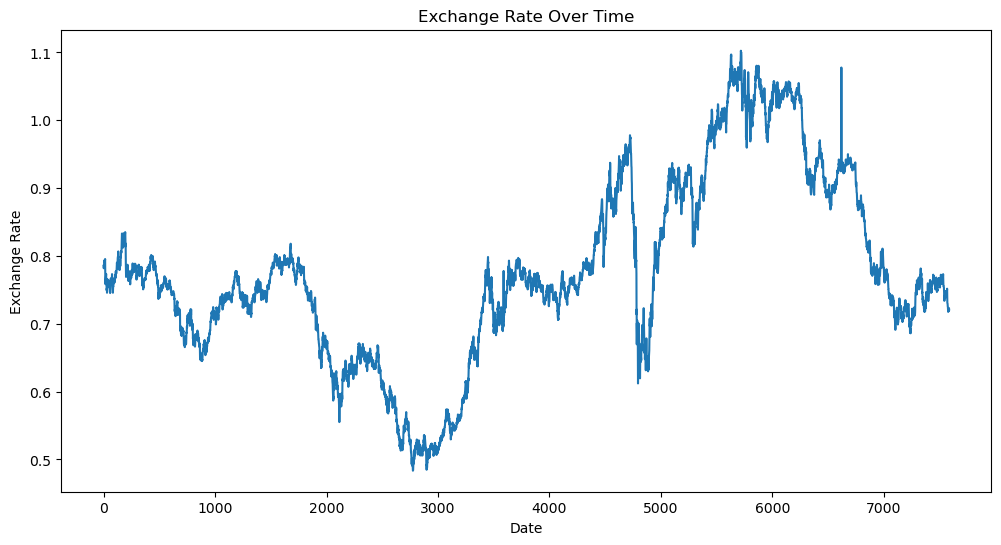

In [28]:
plt.figure(figsize=(12, 6))
plt.plot(data['Ex_rate'])
plt.title('Exchange Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.show()

**Stationarity Check**

In [ ]:
#Augmented Dickey-Fuller (ADF) test.

In [29]:
from statsmodels.tsa.stattools import adfuller


In [ ]:
# Perform ADF test

In [31]:
result = adfuller(data['Ex_rate'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: -1.6649941807380784
p-value: 0.44923273535982894


**Differencing**

In [33]:
data_diff = data['Ex_rate'].diff().dropna()


In [ ]:
# Plot the differenced data

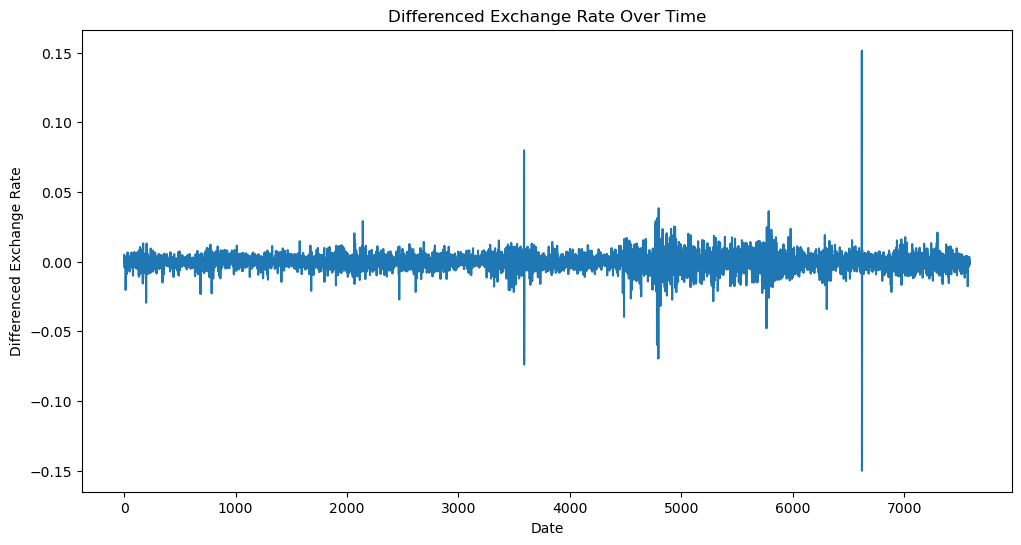

In [34]:
plt.figure(figsize=(12, 6))
plt.plot(data_diff)
plt.title('Differenced Exchange Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Differenced Exchange Rate')
plt.show()

In [ ]:
# Re-check stationarity

In [35]:
result_diff = adfuller(data_diff)
print('ADF Statistic (differenced):', result_diff[0])
print('p-value (differenced):', result_diff[1])

ADF Statistic (differenced): -99.39343120118623
p-value (differenced): 0.0


**Plot ACF and PACF**

In [ ]:
#Plot the ACF and PACF of the differenced data.

In [36]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

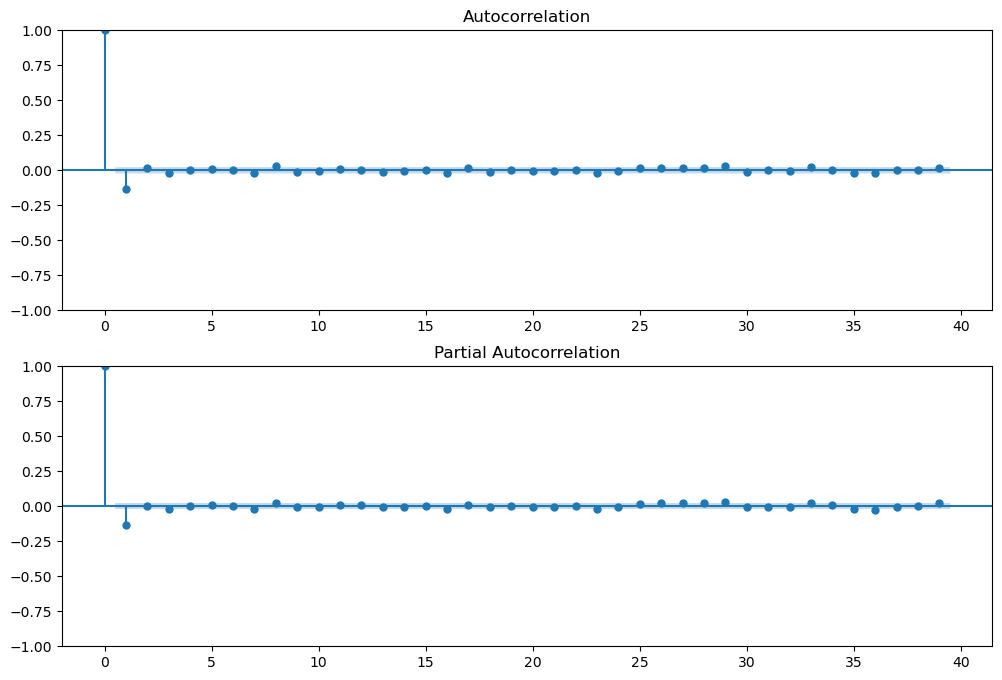

In [37]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(data_diff, ax=ax[0])
plot_pacf(data_diff, ax=ax[1])
plt.show()

**Model Selection and Fitting**

In [ ]:
#Fit an ARIMA model.

In [38]:
from statsmodels.tsa.arima.model import ARIMA

In [44]:
p = 1
d = 1
q = 1

In [45]:
# Fit ARIMA model
model = ARIMA(data['Ex_rate'], order=(p, d, q))  # replace p, d, q with the values determined from ACF/PACF plots
model_fit = model.fit()

C:\Users\Lenovo\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [46]:
# Print the model summary
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 7588
Model:                 ARIMA(1, 1, 1)   Log Likelihood               28054.161
Date:                Wed, 07 Aug 2024   AIC                         -56102.322
Time:                        15:34:35   BIC                         -56081.519
Sample:                             0   HQIC                        -56095.182
                               - 7588                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1268      0.045     -2.797      0.005      -0.216      -0.038
ma.L1         -0.0046      0.045     -0.101      0.920      -0.094       0.085
sigma2      3.596e-05   9.94e-08    361.604      0.0

**Model Diagnostics**

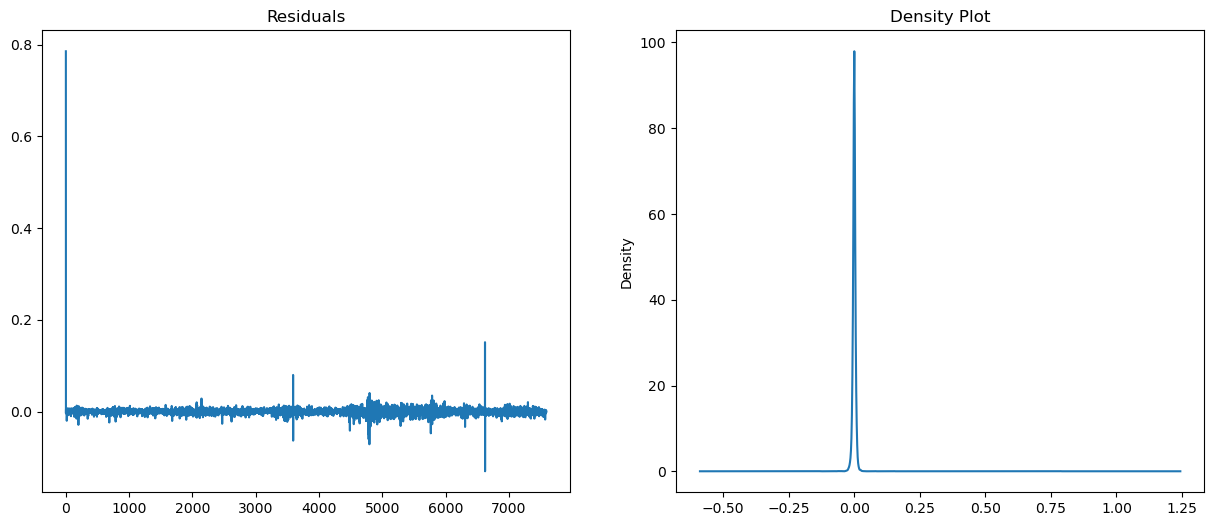

In [47]:
# Plot residuals
residuals = model_fit.resid
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
residuals.plot(ax=ax[0])
ax[0].set_title('Residuals')
residuals.plot(kind='kde', ax=ax[1])
ax[1].set_title('Density Plot')
plt.show()

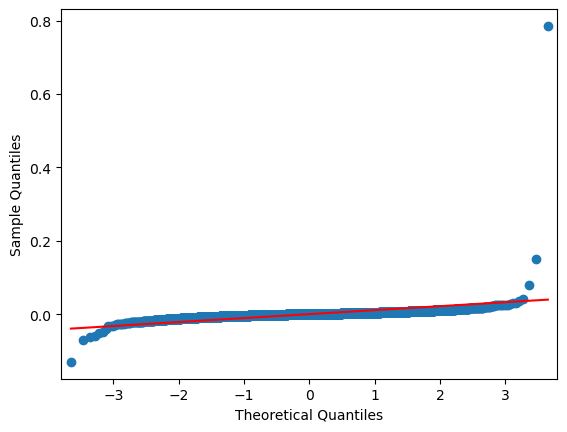

In [48]:
# Perform a QQ plot
from statsmodels.graphics.gofplots import qqplot
qqplot(residuals, line='s')
plt.show()


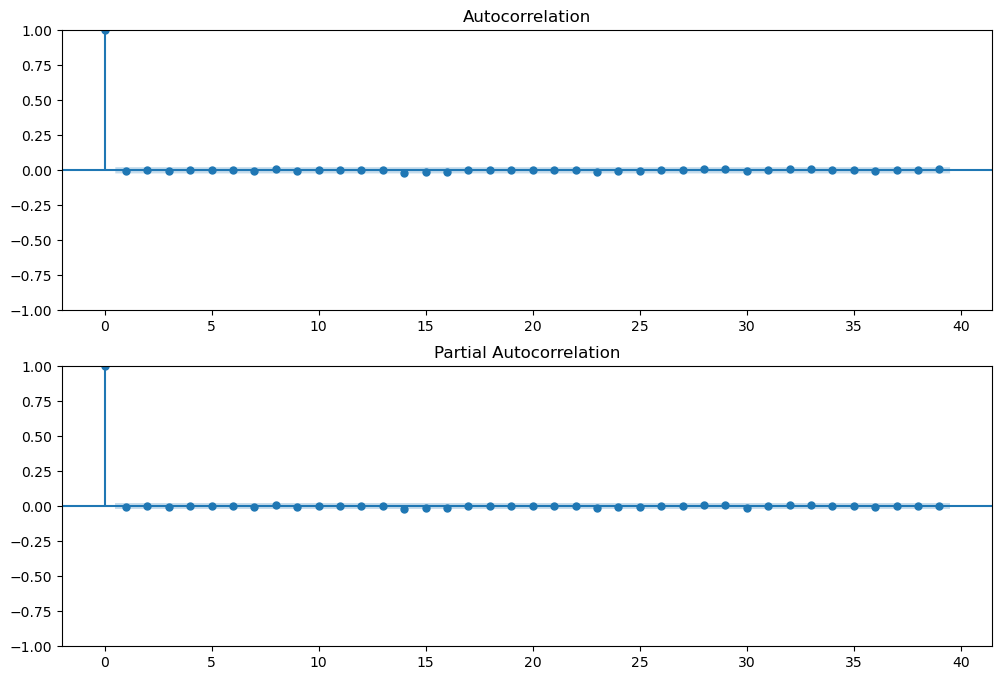

In [49]:
# Check ACF and PACF of residuals
fig, ax = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(residuals, ax=ax[0])
plot_pacf(residuals, ax=ax[1])
plt.show()

In [50]:
# Forecast future values
forecast_steps = 10  # specify the number of steps to forecast
forecast = model_fit.forecast(steps=forecast_steps)

**Forecasting**

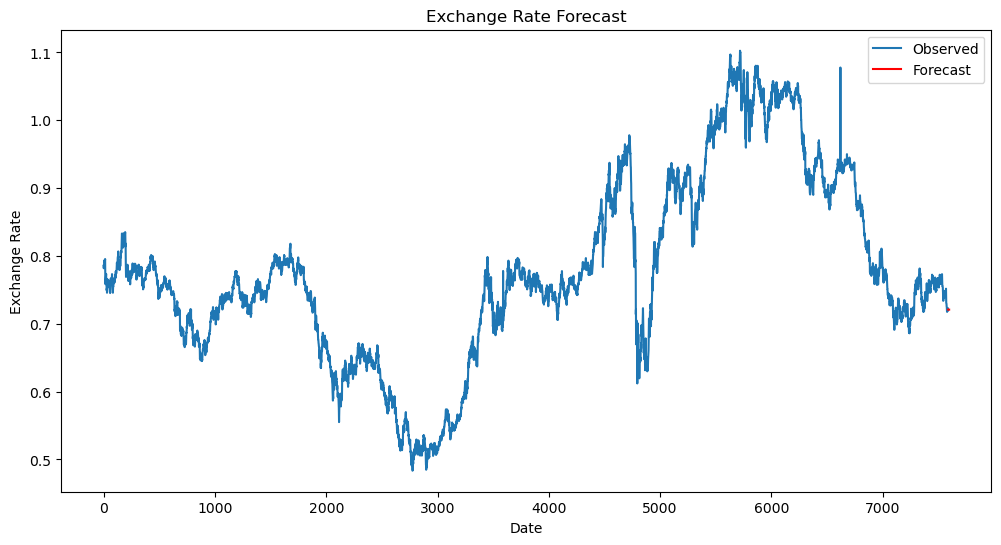

In [51]:
# Plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(data['Ex_rate'], label='Observed')
plt.plot(forecast, label='Forecast', color='red')
plt.title('Exchange Rate Forecast')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.show()